# Azolla pinnata — Approche 1 : Prédiction du taux de croissance relatif (TCR)

Modèle **pré-expérimental** : prédire le TCR d'un bac à partir de ses conditions de culture initiales.

| Élément | Choix | Justification |
|---|---|---|
| **Cible** | TCR = (ln M₁ − ln M₀)/(t₁−t₀) | Indicateur normalisé de croissance (Hunt, 1982) |
| **Unité statistique** | le bac (n=20) | Évite la pseudo-réplication des mesures journalières |
| **Validation** | LOOCV | Adaptée au très faible effectif |
| **Métriques** | RMSE, MAE | Cohérentes avec le mémoire |
| **Modèles** | Linéaire, Ridge, RF, XGBoost | Du plus simple au plus complexe (parcimonie) |
| **Interprétabilité** | SHAP | Importance des variables du meilleur modèle |

**Données :** `dataset azolla_v3.xlsx`, feuille `Feuil2` (3ᵉ feuille) — la plus complète : biomasse
initiale/finale par bac, composition élémentaire, bloc. Composition relue depuis
`data/medium_composition.csv`. Température/humidité agrégées depuis `data/tmp_and_humidity.txt`.

**Conception :** 24 bacs réduits à **20** pour cohérence avec le jeu biochimique (voir section dédiée).
Plan déséquilibré, sans témoin.

> ⚠️ Limite : 4 compositions de milieu distinctes seulement → le modèle apprend surtout des
> moyennes de groupe ; importance des variables **exploratoire**.

## 0. Installation des dépendances

In [1]:
%pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost shap openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Imports et configuration globale

**Reproductibilité :** `RANDOM_STATE = 42` est utilisé pour (a) les modèles stochastiques (RF,
XGBoost) et (b) le tirage aléatoire des bacs retirés pour passer à n=20 → résultats identiques à
chaque exécution.

**Constantes :** `T_DAYS=21` (durée), `LUX_BY_TABLE` (éclairement par bloc : 1=1141, 2=834,
3=727 lux), `N_TARGET=20` (effectif visé).

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb

sns.set_theme(style="whitegrid", context="notebook")
# DejaVu Sans contient les glyphes Unicode (ex. exposant ⁻¹) absents d'Arial
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = True
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

DATA = "../data/dataset azolla_v3.xlsx"
SHEET = "Feuil2"                                   # 3e feuille : la plus complète
COMPOSITION_CSV = "../data/medium_composition.csv"
TEMP_HUM_TXT = "../data/tmp_and_humidity.txt"
OUTDIR = Path("../outputs"); OUTDIR.mkdir(exist_ok=True)

T_DAYS = 21
LUX_BY_TABLE = {1: 1141, 2: 834, 3: 727}           # éclairement (lux) par bloc
N_TARGET = 20

def savefig(name):
    plt.savefig(OUTDIR / name, bbox_inches="tight", dpi=150)
    print("Figure enregistrée :", OUTDIR / name)

## 1. Chargement et nettoyage

Lecture de la feuille `Feuil2` de la v3. On normalise les noms de colonnes, on construit
`bac_id = Medium_Bloc_Bac` (le n° de bac se répète entre blocs), et on garde les colonnes utiles :
pH, biomasse initiale **réelle par bac** (`biomasse_initiale_g`), biomasse finale, bloc.

In [3]:
raw = pd.read_excel(DATA, sheet_name=SHEET, header=0)
raw.columns = [str(col).strip() for col in raw.columns]
raw = raw.rename(columns={"biomasse_initiale_g": "M0", "Biomasse_finale_g": "M21"})
raw["date"] = pd.to_datetime(raw["date"])
raw["bac_id"] = (raw["Medium"].astype(str) + "_Bloc" + raw["Bloc"].astype("Int64").astype(str)
                 + "_B" + raw["Bac"].astype("Int64").astype(str))
print("Bacs distincts :", raw["bac_id"].nunique())
print("Dates de mesure :", sorted(raw["date"].dt.date.unique()))
print("M0 (biomasse initiale) — min/max :", raw["M0"].min(), "/", raw["M0"].max())
raw[["Medium","Bloc","Bac","date","pH","M0","M21"]].head()

Bacs distincts : 24
Dates de mesure : [datetime.date(2026, 5, 18), datetime.date(2026, 5, 19), datetime.date(2026, 5, 20), datetime.date(2026, 5, 21), datetime.date(2026, 5, 27), datetime.date(2026, 5, 29)]
M0 (biomasse initiale) — min/max : 33.0 / 39.0


,Medium,Bloc,Bac,date,pH,M0,M21
0,NPK,1,1,2026-05-18,6.86,36.0,67.723
1,NPK,1,1,2026-05-18,6.58,36.0,67.723
2,NPK,1,1,2026-05-18,6.33,36.0,67.723
3,NPK,1,2,2026-05-18,6.12,37.0,87.656
4,NPK,1,2,2026-05-18,6.07,37.0,87.656


## 2. Agrégation par bac (unité statistique = le bac)

~18 lignes de pH par bac (3 points × 6 jours) → agrégation au niveau du bac (évite la
pseudo-réplication) :
- `pH_mean` / `pH_std`,
- `M0` (réel, variable d'un bac à l'autre dans la v3) et `M21`,
- `light_lux` (déduit du bloc),
- **`TCR`** = ln(M21/M0)/T (Hunt 1982).

In [4]:
ph_agg = raw.groupby("bac_id")["pH"].agg(pH_mean="mean", pH_std="std").reset_index()
bio = raw.groupby("bac_id")[["M0", "M21"]].first().reset_index()
meta = raw.groupby("bac_id")[["Medium", "Bloc"]].first().reset_index()

bac = meta.merge(bio, on="bac_id").merge(ph_agg, on="bac_id")
bac["light_lux"] = bac["Bloc"].map(LUX_BY_TABLE)
bac["TCR"] = np.log(bac["M21"] / bac["M0"]) / T_DAYS

print("Bacs :", len(bac))
print(bac.groupby("Medium").size())
bac.sort_values(["Medium", "Bloc"]).reset_index(drop=True)

Bacs : 24
Medium
IRR2                 7
Modified Hoagland    7
NPK                  3
Yoshida              7
dtype: int64


,bac_id,Medium,Bloc,M0,M21,pH_mean,pH_std,light_lux,TCR
0,IRR2_Bloc1_B1,IRR2,1,36.0,72.342,5.154444,0.333911,1141,0.033233
1,IRR2_Bloc1_B2,IRR2,1,37.0,84.153,5.194444,0.434853,1141,0.039129
2,IRR2_Bloc1_B3,IRR2,1,34.0,46.600,5.103889,0.417558,1141,0.015011
3,IRR2_Bloc1_B4,IRR2,1,35.0,57.986,5.395000,0.232477,1141,0.024041
4,IRR2_Bloc2_B1,IRR2,2,34.0,53.229,5.630000,0.422207,834,0.021345
5,IRR2_Bloc2_B2,IRR2,2,37.0,91.055,5.371111,0.501538,834,0.042883
6,IRR2_Bloc2_B3,IRR2,2,37.0,76.676,5.139444,0.376992,834,0.034699
7,Modified Hoagland_Bloc2_B1,Modified Hoagland,2,37.0,76.687,5.412778,0.275719,834,0.034705
8,Modified Hoagland_Bloc2_B2,Modified Hoagland,2,38.0,94.224,5.006667,0.395757,834,0.043242
9,Modified Hoagland_Bloc2_B3,Modified Hoagland,2,34.0,61.315,5.086111,0.365532,834,0.028079


## 3. Température et humidité (agrégation du capteur)

Le fichier `tmp_and_humidity.txt` provient d'un **capteur unique de salle** (un seul numéro de
série) enregistrant ~toutes les 5 min. On l'agrège en **moyennes journalières** (température,
humidité), puis on calcule la **moyenne sur la période expérimentale**.

> ⚠️ **Point méthodologique important :** ce capteur mesure l'ambiance de la salle, identique pour
> tous les bacs. La moyenne par bac est donc la **même valeur pour tous les bacs** (variance nulle).
> Ces variables sont incluses comme demandé, mais elles **ne peuvent pas discriminer** les bacs
> entre eux : leur importance dans le modèle sera ~nulle (comportement attendu, à déclarer dans les
> résultats). L'agrégation journalière reste utile pour **documenter les conditions réelles** de
> culture dans le mémoire.

In [5]:
# Le txt a 6 colonnes ; la 6e (n° de série) n'apparaît que sur la 1re ligne → on lit par position
th = pd.read_csv(TEMP_HUM_TXT, skiprows=1, header=None,
                 usecols=[1, 2, 3], names=["ts", "temp_C", "humidity_pct"])
th["ts"] = pd.to_datetime(th["ts"], errors="coerce")
th = th.dropna(subset=["ts"])
th["day"] = th["ts"].dt.date

# Moyennes journalières (utile pour documenter les conditions)
daily = th.groupby("day")[["temp_C", "humidity_pct"]].mean().reset_index()
print("Jours couverts :", len(daily))
print(daily.round(2).to_string(index=False))

# Restriction à la fenêtre expérimentale (jours de mesure pH) puis moyenne globale
exp_days = set(raw["date"].dt.date.unique())
mask = daily["day"].isin(exp_days)
temp_mean = daily.loc[mask, "temp_C"].mean()
hum_mean = daily.loc[mask, "humidity_pct"].mean()
print(f"\nMoyennes sur la période : temp={temp_mean:.2f} °C, humidité={hum_mean:.2f} %")

# Affectées à TOUS les bacs (constantes — voir avertissement ci-dessus)
bac["temp_mean"] = temp_mean
bac["humidity_mean"] = hum_mean

Jours couverts : 26
       day  temp_C  humidity_pct
2026-05-11   26.17         60.94
2026-05-12   22.86         60.25
2026-05-13   22.93         61.39
2026-05-14   23.02         62.84
2026-05-15   22.74         65.16
2026-05-16   23.78         67.26
2026-05-17   24.78         57.43
2026-05-18   22.46         64.17
2026-05-19   22.33         65.25
2026-05-20   22.27         64.81
2026-05-21   22.75         65.31
2026-05-22   22.94         65.06
2026-05-23   23.11         64.00
2026-05-24   23.14         63.50
2026-05-25   23.29         64.41
2026-05-26   23.33         64.63
2026-05-27   23.48         64.18
2026-05-28   23.56         64.12
2026-05-29   23.72         63.29
2026-05-30   23.94         63.41
2026-05-31   24.16         63.04
2026-06-01   24.29         62.73
2026-06-02   24.81         63.49
2026-06-03   25.12         61.35
2026-06-04   24.38         62.16
2026-06-05   23.92         62.61

Moyennes sur la période : temp=22.83 °C, humidité=64.50 %


Figure enregistrée : ../outputs/00_conditions_salle.png


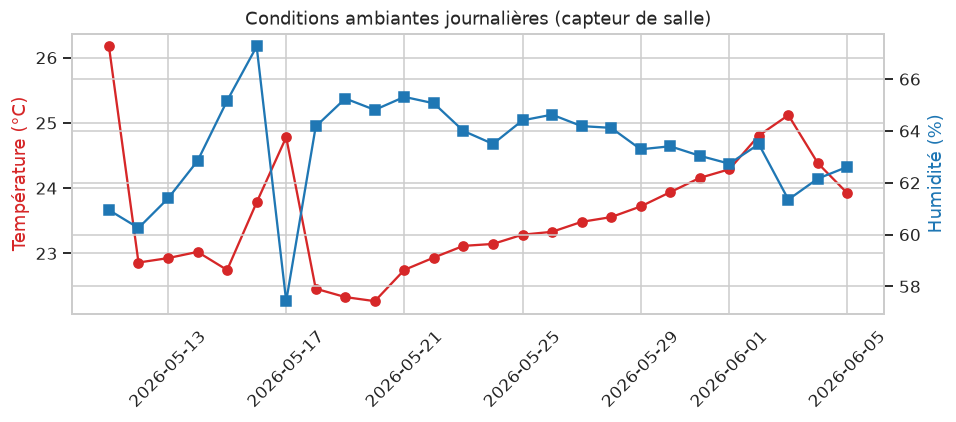

In [6]:
# Figure documentaire : conditions journalières de la salle
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(daily["day"], daily["temp_C"], "o-", color="tab:red", label="Température (°C)")
ax1.set_ylabel("Température (°C)", color="tab:red"); ax1.tick_params(axis="x", rotation=45)
ax2 = ax1.twinx()
ax2.plot(daily["day"], daily["humidity_pct"], "s-", color="tab:blue", label="Humidité (%)")
ax2.set_ylabel("Humidité (%)", color="tab:blue")
ax1.set_title("Conditions ambiantes journalières (capteur de salle)")
plt.tight_layout(); savefig("00_conditions_salle.png"); plt.show()

#### Lecture de la figure 0 (conditions ambiantes) — insights attendus

Figure **documentaire**, pas prédictive. Deux axes : température (rouge, °C) et humidité (bleu, %)
en moyenne journalière.

- *À regarder :* la **stabilité** des conditions. Une température ~constante autour de 23 °C et une
  humidité ~64 % confirment un environnement de culture maîtrisé (pas de dérive thermique/hygrométrique
  majeure sur la période).
- *Pic initial du 11/05 (~26 °C)* : journée de mise en place, hors fenêtre d'analyse des bacs
  (mesures bac à partir du 18/05).
- *Pourquoi ces variables ne servent pas de prédicteurs :* elles proviennent d'un **capteur unique de
  salle** → identiques pour tous les bacs un jour donné. Elles décrivent le **contexte** (à citer dans
  les Matériels & Méthodes) mais ne peuvent pas expliquer les écarts **entre** bacs. C'est pourquoi
  leur importance dans le modèle est nulle (section 8).

## 4. Réduction à n=20 (plan le plus équilibré possible)

L'échantillon de 24 bacs est ramené à **20** pour cohérence avec le jeu biochimique (20 bacs dosés).
On vise le plan **le plus équilibré possible** entre les milieux sur-représentés.

**Pourquoi 6/6/5 et pas 5/5/7 :** le contrôle NPK (n=3) est conservé intégralement ; il reste donc
17 bacs à répartir sur 3 milieux (IRR2, Yoshida, Modified Hoagland). 17 n'étant pas divisible par 3,
la partition entière la plus équilibrée est **6/6/5** (un plan 6/6/6 est impossible). Un plan
équilibré limite la domination d'un milieu dans la fonction de perte et dans l'ANOVA — préférable
au plan 5/5/7.

**Règle de retrait (reproductible, `RANDOM_STATE`) :**
1. **Qualité d'abord** : retrait prioritaire des bacs au relevé de pH incomplet (`IRR2_Bloc1_B4`).
2. **Tailles cibles** {IRR2:6, Yoshida:6, Modified Hoagland:5} atteintes par tirage **aléatoire**
   (graine fixée) des bacs à conserver dans chaque milieu, après retrait des incomplets. NPK intact.

Le tirage aléatoire évite toute sélection arbitraire des bacs « favorables ».

In [7]:
# Tailles cibles : plan le plus équilibré possible (NPK contrôle conservé intégralement)
TARGET_SIZES = {"NPK": 3, "IRR2": 6, "Yoshida": 6, "Modified Hoagland": 5}

# 1) Bacs au pH incomplet (qualité des données) — retirés en priorité
ph_counts = raw.groupby("bac_id")["pH"].count()
typical = ph_counts.mode().iloc[0]
incomplete = set(ph_counts[ph_counts < typical].index)
print("Bacs incomplets (pH) :", sorted(incomplete))

# 2) Pour chaque milieu : on retire d'abord les incomplets, puis on tire aléatoirement
#    (graine fixée) les bacs CONSERVÉS jusqu'à la taille cible.
rng = np.random.default_rng(RANDOM_STATE)
keep_ids = []
for medium, target in TARGET_SIZES.items():
    ids = bac.loc[bac["Medium"] == medium, "bac_id"].tolist()
    complete_ids = [b for b in ids if b not in incomplete]
    incomplete_ids = [b for b in ids if b in incomplete]
    if len(complete_ids) >= target:
        kept = list(rng.choice(complete_ids, size=target, replace=False))
    else:
        kept = complete_ids + list(rng.choice(incomplete_ids,
                                              size=target - len(complete_ids), replace=False))
    keep_ids += kept

bac20 = bac[bac["bac_id"].isin(keep_ids)].reset_index(drop=True)
dropped = sorted(set(bac["bac_id"]) - set(keep_ids))
print("Bacs retirés (total) :", dropped)
print("\nEffectif final :", len(bac20))
print(bac20.groupby("Medium").size())

Bacs incomplets (pH) : ['IRR2_Bloc1_B4']
Bacs retirés (total) : ['IRR2_Bloc1_B4', 'Modified Hoagland_Bloc2_B1', 'Modified Hoagland_Bloc2_B3', 'Yoshida_Bloc3_B2']

Effectif final : 20
Medium
IRR2                 6
Modified Hoagland    5
NPK                  3
Yoshida              6
dtype: int64


## 5. Composition élémentaire du milieu

Chargée depuis `data/medium_composition.csv` (générée à partir de la 3ᵉ feuille de la v3).
Si le CSV est utilisable, ses colonnes deviennent des variables ; sinon repli one-hot.

In [8]:
def load_medium_features(bac_df, csv_path=COMPOSITION_CSV):
    comp = pd.read_csv(csv_path)
    comp = comp.rename(columns={comp.columns[0]: "Medium"})
    nutrient_cols = [col for col in comp.columns if col != "Medium"]
    comp[nutrient_cols] = comp[nutrient_cols].apply(pd.to_numeric, errors="coerce")
    filled = comp[nutrient_cols].notna().any().any()
    usable = filled and comp.set_index("Medium").loc[
        bac_df["Medium"].unique(), nutrient_cols].notna().any(axis=1).all()
    if usable:
        merged = bac_df.merge(comp, on="Medium", how="left")
        print(f"Composition CSV utilisée ({len(nutrient_cols)} éléments) : {nutrient_cols}")
        return merged, nutrient_cols, "composition"
    print("CSV vide/incomplet -> encodage one-hot du milieu.")
    dummies = pd.get_dummies(bac_df["Medium"], prefix="med")
    merged = pd.concat([bac_df, dummies], axis=1)
    return merged, list(dummies.columns), "onehot"

bac_feat, nutrient_cols, mode = load_medium_features(bac20)
bac_feat.head()

Composition CSV utilisée (12 éléments) : ['N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn', 'Mo', 'B', 'Cu', 'Zn', 'Co']


,bac_id,Medium,Bloc,M0,M21,pH_mean,pH_std,light_lux,TCR,temp_mean,...,K,Ca,Mg,Fe,Mn,Mo,B,Cu,Zn,Co
0,IRR2_Bloc1_B1,IRR2,1,36.0,72.342,5.154444,0.333911,1141,0.033233,22.833912,...,0.5,0.44,0.4,0.0556,0.0687,0.149,0.00194,0.0001,0.000101,0.000101
1,IRR2_Bloc1_B2,IRR2,1,37.0,84.153,5.194444,0.434853,1141,0.039129,22.833912,...,0.5,0.44,0.4,0.0556,0.0687,0.149,0.00194,0.0001,0.000101,0.000101
2,IRR2_Bloc1_B3,IRR2,1,34.0,46.600,5.103889,0.417558,1141,0.015011,22.833912,...,0.5,0.44,0.4,0.0556,0.0687,0.149,0.00194,0.0001,0.000101,0.000101
3,IRR2_Bloc2_B1,IRR2,2,34.0,53.229,5.630000,0.422207,834,0.021345,22.833912,...,0.5,0.44,0.4,0.0556,0.0687,0.149,0.00194,0.0001,0.000101,0.000101
4,IRR2_Bloc2_B2,IRR2,2,37.0,91.055,5.371111,0.501538,834,0.042883,22.833912,...,0.5,0.44,0.4,0.0556,0.0687,0.149,0.00194,0.0001,0.000101,0.000101


### Matrice de features X et cible y

X = composition (ou one-hot) + `light_lux` + `pH_mean` + `M0` + `temp_mean` + `humidity_mean`.
y = `TCR`.

`temp_mean` / `humidity_mean` sont constantes (capteur de salle) → neutralisées par le
`StandardScaler`, importance attendue ~nulle. `M0` est désormais **réelle et variable** (v3).

In [9]:
feature_cols = nutrient_cols + ["light_lux", "pH_mean", "M0", "temp_mean", "humidity_mean"]
X = bac_feat[feature_cols].astype(float).fillna(0.0)
y = bac_feat["TCR"].astype(float)
print("Mode composition :", mode)
print("Features :", feature_cols)
print("X shape :", X.shape, "| y (TCR) shape :", y.shape)

Mode composition : composition
Features : ['N', 'P', 'K', 'Ca', 'Mg', 'Fe', 'Mn', 'Mo', 'B', 'Cu', 'Zn', 'Co', 'light_lux', 'pH_mean', 'M0', 'temp_mean', 'humidity_mean']
X shape : (20, 17) | y (TCR) shape : (20,)


## 6. Exploration des données

Boxplot du TCR par milieu (points individuels) + nuage TCR vs pH moyen.

Figure enregistrée : ../outputs/01_eda.png


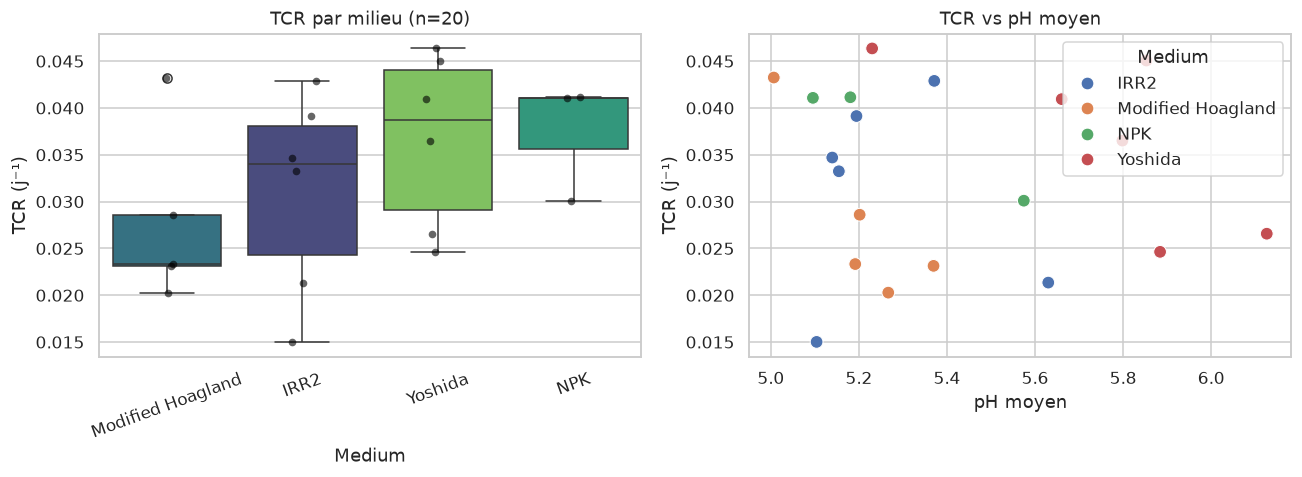

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
order = bac_feat.groupby("Medium")["TCR"].median().sort_values().index
sns.boxplot(data=bac_feat, x="Medium", y="TCR", order=order, hue="Medium",
            legend=False, ax=ax[0], palette="viridis")
sns.stripplot(data=bac_feat, x="Medium", y="TCR", order=order, ax=ax[0],
              color="black", size=5, alpha=.6)
ax[0].set_title("TCR par milieu (n=20)"); ax[0].set_ylabel("TCR (j⁻¹)")
ax[0].tick_params(axis="x", rotation=20)
sns.scatterplot(data=bac_feat, x="pH_mean", y="TCR", hue="Medium", s=70, ax=ax[1])
ax[1].set_title("TCR vs pH moyen"); ax[1].set_xlabel("pH moyen"); ax[1].set_ylabel("TCR (j⁻¹)")
plt.tight_layout(); savefig("01_eda.png"); plt.show()

#### Lecture de la figure 1 — insights attendus

- **Boxplot** : l'ordre des médianes indique le milieu le plus favorable ; des boîtes qui se
  chevauchent annoncent des différences difficiles à distinguer. Une boîte « haute » = forte
  variabilité intra-milieu (plafonne la prédiction).
- **Nuage TCR vs pH** : une inclinaison suggérerait un lien pH→croissance ; un nuage diffus
  indique l'absence de relation linéaire simple.

## 7. Benchmark des modèles par LOOCV

Mêmes 4 modèles régularisés (cf. tableau), `StandardScaler` pour les modèles linéaires, LOOCV
(n=20 partitions), métriques RMSE et MAE.

| Modèle | Hyperparamètres | Justification |
|---|---|---|
| Régression linéaire | (aucun) | Référence interprétable |
| Ridge | `alpha=10.0` | Régularisation L2 forte (faible n) |
| Random Forest | `n_estimators=300, max_depth=2, min_samples_leaf=3` | Complexité bridée |
| XGBoost | `n_estimators=200, max_depth=2, learning_rate=0.05, reg_lambda=5, reg_alpha=1` | Boosting bridé |

In [11]:
def make_models():
    return {
        "Régression linéaire": make_pipeline(StandardScaler(), LinearRegression()),
        "Ridge":               make_pipeline(StandardScaler(), Ridge(alpha=10.0)),
        "Random Forest":       RandomForestRegressor(
            n_estimators=300, max_depth=2, min_samples_leaf=3, random_state=RANDOM_STATE),
        "XGBoost":             xgb.XGBRegressor(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            reg_lambda=5.0, reg_alpha=1.0, random_state=RANDOM_STATE),
    }

def loocv_eval(model, X, y):
    loo = LeaveOneOut(); preds = np.empty(len(y)); truth = y.to_numpy(); Xv = X.to_numpy()
    for tr, te in loo.split(Xv):
        model.fit(Xv[tr], truth[tr]); preds[te] = model.predict(Xv[te])
    return preds

results, preds_store = [], {}
for name, model in make_models().items():
    preds = loocv_eval(model, X, y); preds_store[name] = preds
    results.append({"Modèle": name,
                    "RMSE": np.sqrt(mean_squared_error(y, preds)),
                    "MAE": mean_absolute_error(y, preds)})
res_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
res_df.to_csv(OUTDIR / "model_comparison.csv", index=False)
res_df.round(5)

,Modèle,RMSE,MAE
0,Régression linéaire,0.00590,0.00462
1,Random Forest,0.00593,0.00436
2,Ridge,0.00615,0.00465
3,XGBoost,0.00977,0.00871


Figure enregistrée : ../outputs/02_benchmark_loocv.png


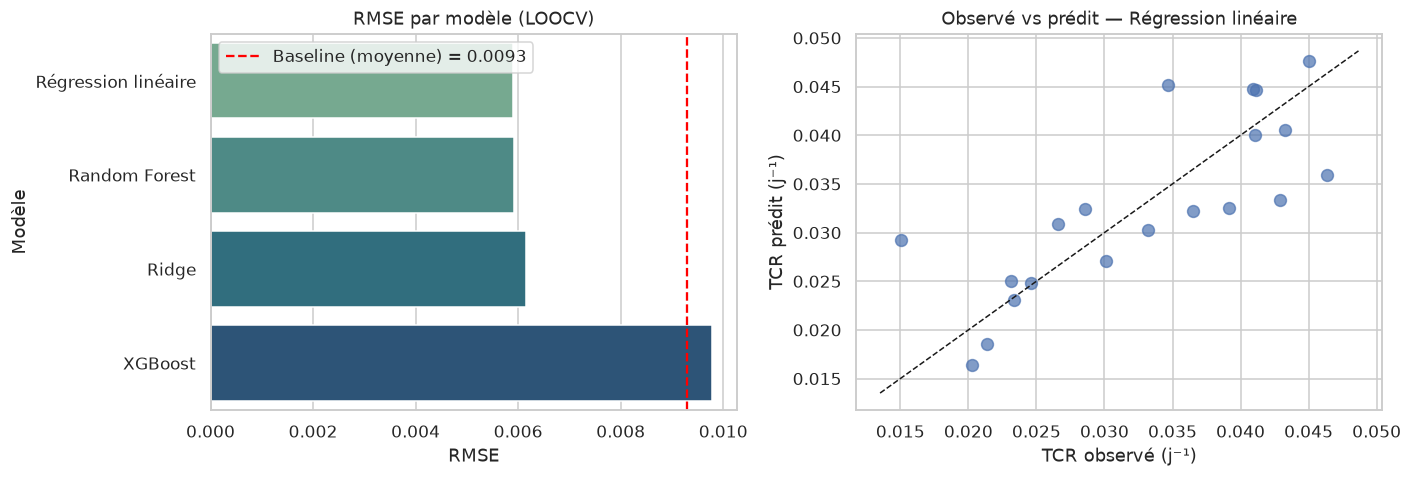

Meilleur modèle (RMSE) : Régression linéaire


In [12]:
baseline_rmse = np.sqrt(mean_squared_error(y, np.full_like(y, y.mean())))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=res_df, x="RMSE", y="Modèle", hue="Modèle", legend=False, ax=ax[0], palette="crest")
ax[0].axvline(baseline_rmse, ls="--", color="red", label=f"Baseline (moyenne) = {baseline_rmse:.4f}")
ax[0].set_title("RMSE par modèle (LOOCV)"); ax[0].legend()
best = res_df.iloc[0]["Modèle"]
ax[1].scatter(y, preds_store[best], s=60, alpha=.7)
lims = [y.min()*.9, y.max()*1.05]; ax[1].plot(lims, lims, "k--", lw=1)
ax[1].set_xlabel("TCR observé (j⁻¹)"); ax[1].set_ylabel("TCR prédit (j⁻¹)")
ax[1].set_title(f"Observé vs prédit — {best}")
plt.tight_layout(); savefig("02_benchmark_loocv.png"); plt.show()
print("Meilleur modèle (RMSE) :", best)

#### Lecture de la figure 2 — insights attendus

- **Barres RMSE** : un modèle n'est utile que si sa barre passe **à gauche** de la baseline rouge.
  Si les modèles simples égalent/battent les complexes → confirme la **parcimonie**.
- **Observé vs prédit** : points proches de la diagonale = bonnes prédictions ; nuage horizontal =
  le modèle se rabat sur la moyenne.

## 8. Importance des variables (modèle retenu) — exploratoire

SHAP si disponible, sinon importances natives / |coefficients|.

Figure enregistrée : ../outputs/03_shap_summary.png


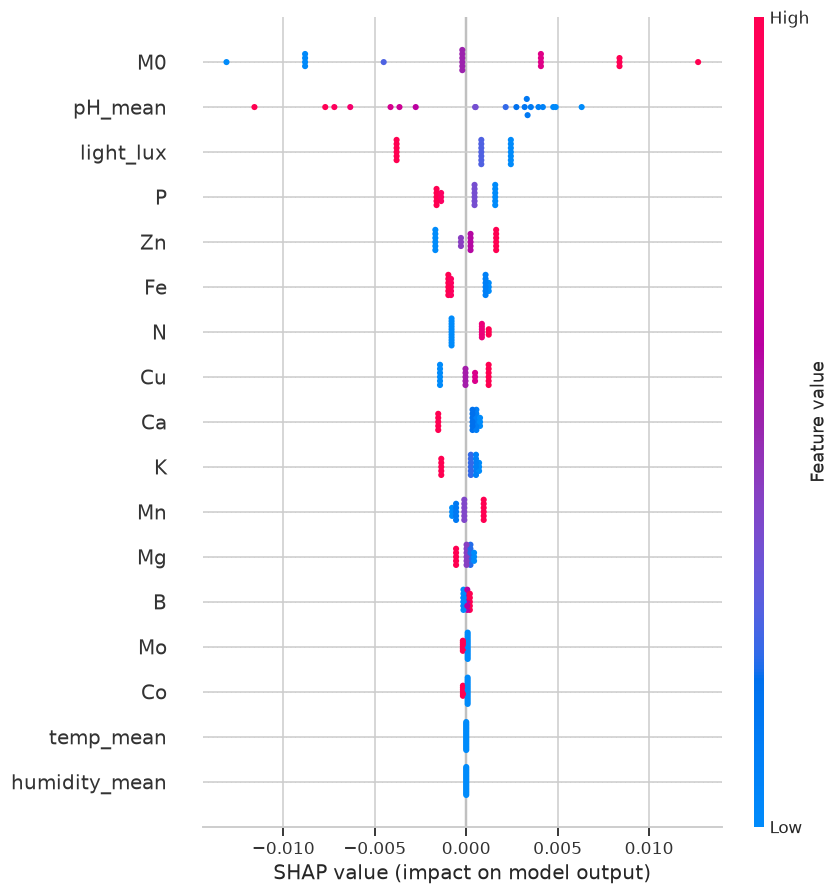

,feature,mean_abs_shap
14,M0,0.005415
13,pH_mean,0.004339
12,light_lux,0.002285
1,P,0.001224
10,Zn,0.001100
5,Fe,0.001004
0,N,0.000882
9,Cu,0.000881
3,Ca,0.000766
2,K,0.000682


In [13]:
best_model = make_models()[best]
best_model.fit(X.to_numpy(), y.to_numpy())
importance = None
try:
    import shap
    if best in ("Random Forest", "XGBoost"):
        sv = shap.TreeExplainer(best_model).shap_values(X)
    else:
        Xs = StandardScaler().fit_transform(X)
        sv = shap.LinearExplainer(best_model.named_steps[list(best_model.named_steps)[-1]], Xs).shap_values(Xs)
    shap.summary_plot(sv, X, feature_names=feature_cols, show=False)
    savefig("03_shap_summary.png"); plt.show()
    importance = pd.DataFrame({"feature": feature_cols, "mean_abs_shap": np.abs(sv).mean(axis=0)}
                              ).sort_values("mean_abs_shap", ascending=False)
except Exception as e:
    print("SHAP indisponible, repli :", e)
    if hasattr(best_model, "feature_importances_"): imp = best_model.feature_importances_
    elif hasattr(best_model[-1], "coef_"): imp = np.abs(best_model[-1].coef_)
    else: imp = np.zeros(len(feature_cols))
    importance = pd.DataFrame({"feature": feature_cols, "importance": imp}
                              ).sort_values("importance", ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance, x=importance.columns[1], y="feature",
                hue="feature", legend=False, palette="flare")
    plt.title(f"Importance des variables — {best}")
    plt.tight_layout(); savefig("03_feature_importance.png"); plt.show()

importance.to_csv(OUTDIR / "feature_importance.csv", index=False)
importance

#### Lecture de la figure 3 — insights attendus

- Variables classées par importance ; la/les variable(s) du haut pèsent le plus.
- `temp_mean`, `humidity_mean` et (le cas échéant) `M0` peu variables → importance attendue
  faible/nulle (normal).
- En mode composition, les éléments (P, K, N…) en tête indiquent les nutriments les plus associés
  au TCR — à confronter à la littérature (interprétation exploratoire).

## 9. Synthèse

- **Données :** v3 `Feuil2`, 20 bacs (réduction documentée depuis 24).
- **Cible :** TCR (Hunt 1982) ; M0 réel par bac.
- **Features :** composition élémentaire (CSV) + lumière + pH moyen + M0 + température + humidité.
- **Validation :** LOOCV ; RMSE, MAE ; `RANDOM_STATE=42`.

**Variables à variance nulle** (température, humidité — capteur de salle ; éventuellement M0) :
incluses comme demandé mais non discriminantes. **TDS/salinité** : non utilisées (colinéaires CE).
**Approche 2 (déplétion CE)** : non implémentée (CE mono-temporelle), discutée théoriquement.
Détails : `RESULTS_AND_LIMITATIONS.md`.